In [9]:

# Import Libraries


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


import warnings
warnings.filterwarnings("ignore")


# Display Settings

pd.set_option('display.max_columns', None)


# Load Dataset


dataset_path = r"C:\Dataset\Sample - Superstore.csv"

df = pd.read_csv(dataset_path, encoding='latin1')

# Preview dataset
print("========== Dataset Preview ==========")
print(df.head())

# Dataset Information

print("\n========== Dataset Info ==========")
print(df.info())

print("\n========== Statistical Summary ==========")
print(df.describe())

# Remove Unnecessary Columns


columns_to_drop = [
    'Row ID',
    'Order ID',
    'Ship Date',
    'Customer ID',
    'Customer Name',
    'Product ID',
    'Country',
    'Postal Code'
]

df.drop(columns=columns_to_drop, inplace=True)

# Missing Values Check


print("\n========== Missing Values ==========")
print(df.isnull().sum())

# Duplicate Records Check


print("\n========== Duplicate Records ==========")
print(df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

print("\n========== Duplicates After Removal ==========")
print(df.duplicated().sum())


# Convert Date Columns


df['Order Date'] = pd.to_datetime(df['Order Date'])


# Feature Engineering


# Extract Year and Month
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month_name()

# Profit Margin Calculation
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100


# Final Dataset Check


print("\n========== Cleaned Dataset ==========")
print(df.head())

print("\nDataset Shape:", df.shape)

========== Dataset Preview ==========
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Co

## Time based analysis

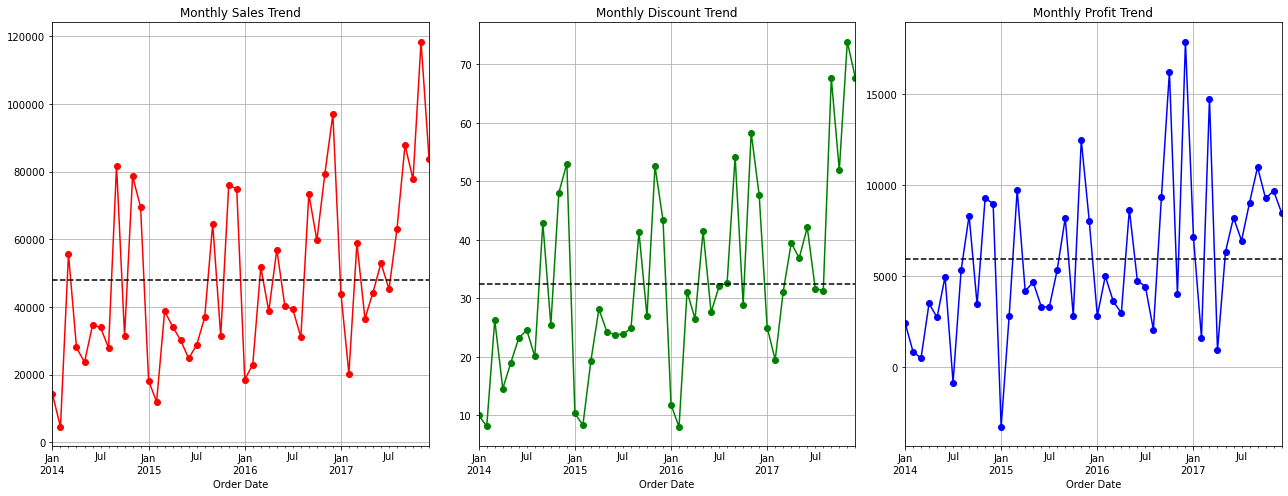

In [21]:
# Monthly Aggregations
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_discount = df.groupby(df['Order Date'].dt.to_period('M'))['Discount'].sum()
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum()

# Average Metrics
avg_sales = monthly_sales.mean()
avg_discount = monthly_discount.mean()
avg_profit = monthly_profit.mean()

# Plot Monthly Trends

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

monthly_sales.plot(ax=axes[0], marker='o', color='red')
axes[0].axhline(avg_sales, linestyle='--', color='black')
axes[0].set_title('Monthly Sales Trend')
axes[0].grid(True)

# Monthly Discount
monthly_discount.plot(ax=axes[1], marker='o', color='green')
axes[1].axhline(avg_discount, linestyle='--', color='black')
axes[1].set_title('Monthly Discount Trend')
axes[1].grid(True)

# Monthly Profit
monthly_profit.plot(ax=axes[2], marker='o', color='blue')
axes[2].axhline(avg_profit, linestyle='--', color='black')
axes[2].set_title('Monthly Profit Trend')
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Geographic Analysis

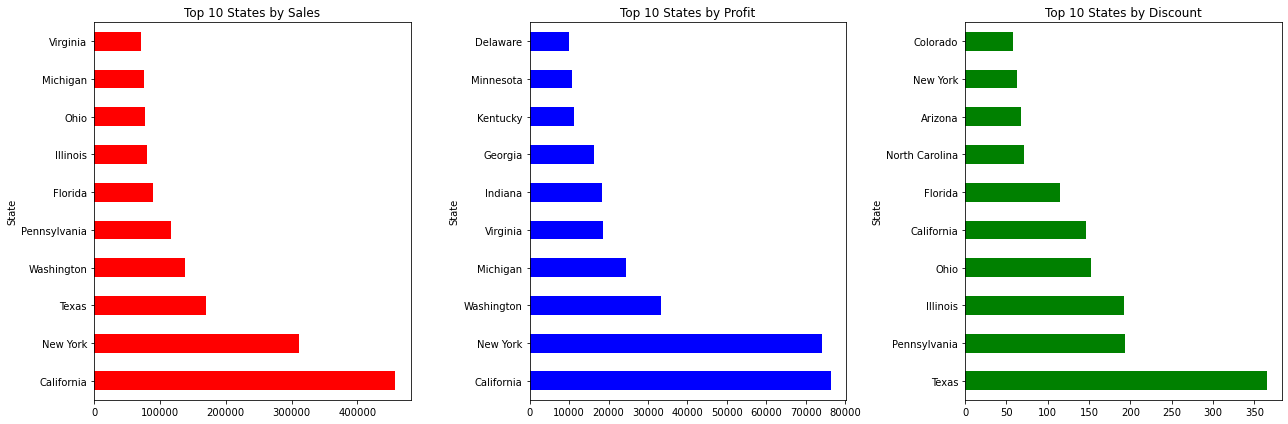

In [23]:
# Top States
top_states_sales = df.groupby('State')['Sales'].sum().nlargest(10)
top_states_profit = df.groupby('State')['Profit'].sum().nlargest(10)
top_states_discount = df.groupby('State')['Discount'].sum().nlargest(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sales by State
top_states_sales.plot(kind='barh', ax=axes[0], color='red')
axes[0].set_title('Top 10 States by Sales')

# Profit by State
top_states_profit.plot(kind='barh', ax=axes[1], color='blue')
axes[1].set_title('Top 10 States by Profit')

# Discount by State
top_states_discount.plot(kind='barh', ax=axes[2], color='green')
axes[2].set_title('Top 10 States by Discount')

plt.tight_layout()
plt.show()

## Product Analysis

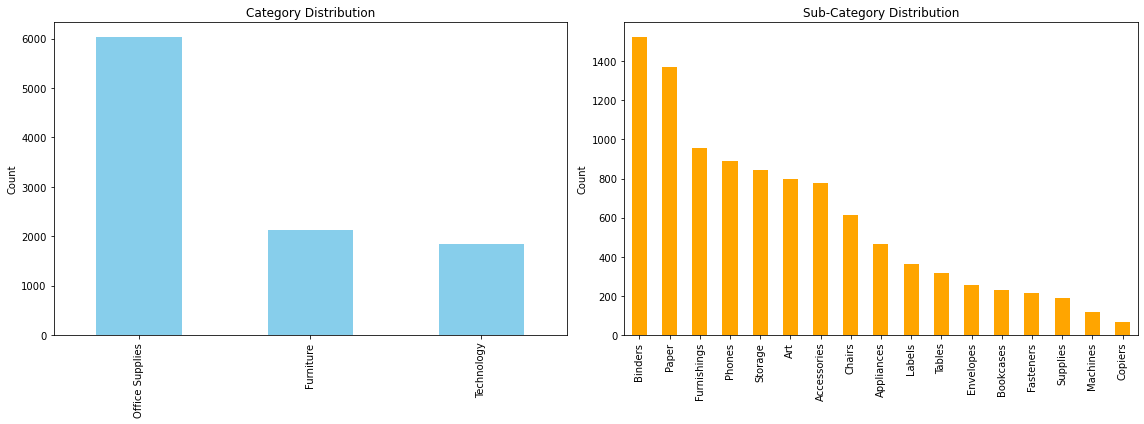

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Category Distribution
df['Category'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color='skyblue'
)

axes[0].set_title('Category Distribution')
axes[0].set_ylabel('Count')

# Sub-Category Distribution
df['Sub-Category'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    color='orange'
)

axes[1].set_title('Sub-Category Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Shipping and Customer Segments

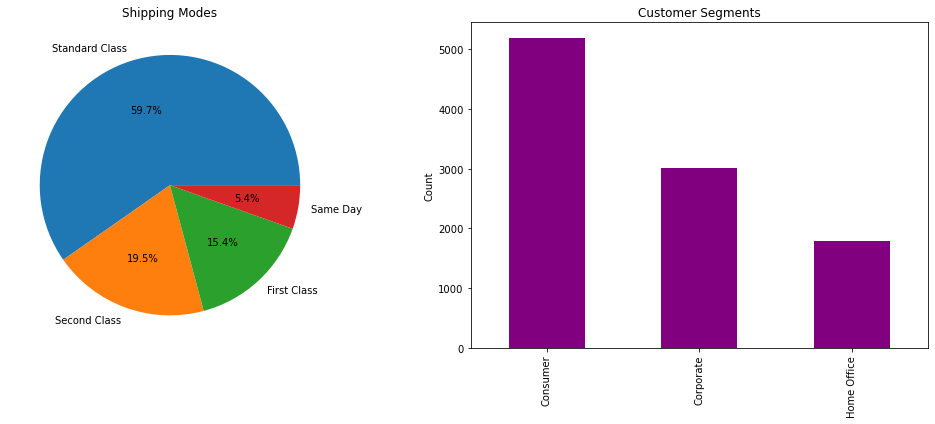

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ship Mode
df['Ship Mode'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[0]
)

axes[0].set_ylabel('')
axes[0].set_title('Shipping Modes')

# Customer Segment
df['Segment'].value_counts().plot(
    kind='bar',
    color='purple',
    ax=axes[1]
)

axes[1].set_title('Customer Segments')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Key Business Insights

## Findings
- Sales generally increased over time, indicating business growth.
- Certain states and cities contributed significantly more revenue.
- Discounts impacted profitability in several regions.
- Technology and Office Supplies categories showed strong performance.
- Customer purchasing behavior differed across segments.

## Recommendations
- Reduce excessive discounts in low-profit regions.
- Focus marketing efforts on high-performing cities and states.
- Improve inventory planning for high-demand categories.
- Use customer segmentation for targeted sales strategies.